In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import BayesSearchCV
from imblearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("combined_data.csv")
df.head()

,Unnamed: 0,CHCKDNY2,_DRDXAR2,SDHBILLS,SDHSTRE1,_SMOKER3,SDLONELY,SDHFOOD1,_CASTHM1,SDHEMPLY,...,_TOTINDA,_CHLDCNT,_RFBING6,MARITAL,_INCOMG1,EMTSUPRT,_SEX,_EDUCAG,ADDEPEV3,year
0,0,2.0,2.0,2.0,5.0,4.0,5.0,5.0,1.0,2.0,...,2.0,1.0,1.0,1.0,9.0,1.0,2.0,3.0,2.0,2023
1,1,2.0,1.0,2.0,5.0,4.0,3.0,5.0,1.0,2.0,...,1.0,1.0,1.0,2.0,9.0,2.0,2.0,3.0,1.0,2023
2,2,2.0,1.0,1.0,3.0,3.0,3.0,5.0,2.0,2.0,...,1.0,1.0,1.0,3.0,1.0,4.0,2.0,2.0,2.0,2023
3,3,2.0,1.0,2.0,5.0,4.0,3.0,5.0,1.0,2.0,...,1.0,1.0,1.0,1.0,9.0,1.0,2.0,3.0,1.0,2023
4,4,2.0,1.0,2.0,2.0,4.0,2.0,4.0,1.0,2.0,...,1.0,1.0,1.0,3.0,5.0,2.0,2.0,3.0,1.0,2023


Original shape: (878455, 28)
Shape after cleaning: (191010, 28) (hapus smua 7)

In [3]:
df_clean = df.copy()

ex = ['EMPLOY1', 'RACEPRV', '_INCOMEG1']

rep = df_clean.columns.difference(ex)

In [4]:
df_clean[rep] = df_clean[rep].replace(7, np.nan)
df_clean = df_clean.replace(9, np.nan)

In [5]:
df_clean = df_clean.dropna()

print(f"Original shape: {df.shape}")
print(f"Shape after cleaning: {df_clean.shape}")

df_clean.head()

Original shape: (878455, 28)
Shape after cleaning: (293598, 28)


,Unnamed: 0,CHCKDNY2,_DRDXAR2,SDHBILLS,SDHSTRE1,_SMOKER3,SDLONELY,SDHFOOD1,_CASTHM1,SDHEMPLY,...,_TOTINDA,_CHLDCNT,_RFBING6,MARITAL,_INCOMG1,EMTSUPRT,_SEX,_EDUCAG,ADDEPEV3,year
2,2.0,2.0,1.0,1.0,3.0,3.0,3.0,5.0,2.0,2.0,...,1.0,1.0,1.0,3.0,1.0,4.0,2.0,2.0,2.0,2023
4,4.0,2.0,1.0,2.0,2.0,4.0,2.0,4.0,1.0,2.0,...,1.0,1.0,1.0,3.0,5.0,2.0,2.0,3.0,1.0,2023
5,5.0,2.0,2.0,2.0,3.0,4.0,3.0,5.0,1.0,2.0,...,1.0,1.0,1.0,3.0,5.0,2.0,2.0,3.0,2.0,2023
6,6.0,2.0,1.0,2.0,5.0,3.0,4.0,5.0,1.0,2.0,...,2.0,1.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,2023
8,8.0,1.0,1.0,2.0,4.0,4.0,3.0,5.0,1.0,2.0,...,2.0,1.0,1.0,3.0,4.0,1.0,2.0,3.0,2.0,2023


In [ ]:
# df_clean = df_clean[df_clean['year'] != 2022]

In [6]:
df_clean.drop(columns=['Unnamed: 0', 'year'], inplace=True)

In [7]:
df_clean['ADDEPEV3'] = df_clean['ADDEPEV3'].replace(2.0, 0.0)

In [8]:
X = df_clean.drop('ADDEPEV3', axis=1)
y = df_clean['ADDEPEV3']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

## SMOTE

In [10]:
smote = SMOTE(sampling_strategy="auto", random_state=42)

In [11]:
df_clean.shape

(293598, 26)

In [12]:
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

## GradientBoostingClassifier

In [13]:
gb_model = GradientBoostingClassifier(random_state=42)

In [14]:
gb_model.fit(X_train_balanced, y_train_balanced)

GradientBoostingClassifier(random_state=42)

In [15]:
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

In [16]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)
roc_auc = roc_auc_score(y_test, y_pred_proba_gb)

In [17]:
print(f"\nGradient Boosting with SMOTE results:")
print(f"Accuracy: {gb_accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting with SMOTE results:
Accuracy: 0.8137
ROC AUC: 0.8047

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89     57006
         1.0       0.64      0.39      0.48     16394

    accuracy                           0.81     73400
   macro avg       0.74      0.66      0.68     73400
weighted avg       0.80      0.81      0.80     73400



## HistGradientBoostingClassifier

In [18]:
hgb_model = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')

hgb_model.fit(X_train, y_train)

y_pred_hgb = hgb_model.predict(X_test)
y_pred_proba_hgb = hgb_model.predict_proba(X_test)[:, 1]

In [20]:
hgb_accuracy = accuracy_score(y_test, y_pred_hgb)
hgb_roc_auc = roc_auc_score(y_test, y_pred_proba_hgb)

print(f"\nHistogram-based Gradient Boosting without SMOTE results:")
print(f"Accuracy: {hgb_accuracy:.4f}")
print(f"ROC AUC: {hgb_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_hgb))


Histogram-based Gradient Boosting without SMOTE results:
Accuracy: 0.7401
ROC AUC: 0.8101

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82     57006
         1.0       0.45      0.72      0.55     16394

    accuracy                           0.74     73400
   macro avg       0.68      0.73      0.68     73400
weighted avg       0.80      0.74      0.76     73400



## RandomForest + Weighted Class

In [21]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [22]:
y_pred = rf_model.predict(X_test)

In [23]:
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"\nRandom Forest with SMOTE results:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC AUC: {rf_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Random Forest with SMOTE results:
Accuracy: 0.8085
ROC AUC: 0.7856

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.95      0.89     57006
         1.0       0.64      0.32      0.43     16394

    accuracy                           0.81     73400
   macro avg       0.74      0.63      0.66     73400
weighted avg       0.79      0.81      0.78     73400



## Random Forest + SMOTE

In [24]:
rfs_model = RandomForestClassifier(random_state=42)
rfs_model.fit(X_train_balanced, y_train_balanced)
y_pred_rfs = rfs_model.predict(X_test)

In [25]:
rfs_accuracy = accuracy_score(y_test, y_pred_rfs)
rfs_roc_auc = roc_auc_score(y_test, rfs_model.predict_proba(X_test)[:, 1])

print(f"\nRandom Forest with SMOTE results:")
print(f"Accuracy: {rfs_accuracy:.4f}")
print(f"ROC AUC: {rfs_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfs))


Random Forest with SMOTE results:
Accuracy: 0.8074
ROC AUC: 0.7848

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.88     57006
         1.0       0.62      0.36      0.46     16394

    accuracy                           0.81     73400
   macro avg       0.73      0.65      0.67     73400
weighted avg       0.79      0.81      0.79     73400



In [26]:
#Summary of results
results_summary = pd.DataFrame({
    'Model': ['Gradient Boosting', 'Histogram-based Gradient Boosting', 'Random Forest', 'Random Forest with SMOTE'],
    'Accuracy': [gb_accuracy, hgb_accuracy, rf_accuracy, rfs_accuracy],
    'ROC AUC': [roc_auc, hgb_roc_auc, rf_roc_auc, rfs_roc_auc]
})

print("\nSummary of Results:")
print(results_summary)


Summary of Results:
                               Model  Accuracy   ROC AUC
0                  Gradient Boosting  0.813706  0.804721
1  Histogram-based Gradient Boosting  0.740136  0.810150
2                      Random Forest  0.808542  0.785620
3           Random Forest with SMOTE  0.807357  0.784796


In [28]:
gb_space = [
    Integer(50, 300, name='n_estimators'),
    Real(0.01, 0.3, name='learning_rate'),
    Integer(3, 10, name='max_depth'),
    Real(0.1, 1.0, name='subsample'),
    Integer(2, 10, name='min_samples_split'),
    Integer(2, 10, name='min_samples_leaf')
]

hgb_space = [
    Integer(50, 300, name='max_iter'),
    Real(0.01, 0.3, name='learning_rate'),
    Integer(3, 10, name='max_depth'),
    Real(0.1, 1.0, name='subsample'),
    Integer(1, 20, name='min_samples_leaf')
]

rf_space = [
    Integer(50, 300, name='n_estimators'),
    Integer(3, 15, name='max_depth'),
    Integer(2, 20, name='min_samples_split'),
    Integer(1, 10, name='min_samples_leaf'),
    Real(0.1, 1.0, name='max_samples')
]

In [25]:
# # Gradient Boosting optimization
# @use_named_args(gb_space)
# def gb_objective(**params):
#     model = GradientBoostingClassifier(random_state=42, **params)
#     return -np.mean(cross_val_score(model, X_train_balanced, y_train_balanced, cv=3, scoring='roc_auc'))

# print("Optimizing Gradient Boosting...")
# gb_result = gp_minimize(gb_objective, gb_space, n_calls=50, random_state=42)

# # Histogram-based Gradient Boosting optimization
# @use_named_args(hgb_space)
# def hgb_objective(**params):
#     model = HistGradientBoostingClassifier(random_state=42, class_weight='balanced', **params)
#     return -np.mean(cross_val_score(model, X_train_balanced, y_train_balanced, cv=3, scoring='roc_auc'))

# print("Optimizing Histogram-based Gradient Boosting...")
# hgb_result = gp_minimize(hgb_objective, hgb_space, n_calls=50, random_state=42)

# # Random Forest optimization
# @use_named_args(rf_space)
# def rf_objective(**params):
#     model = RandomForestClassifier(random_state=42, class_weight='balanced', **params)
#     return -np.mean(cross_val_score(model, X_train_balanced, y_train_balanced, cv=3, scoring='roc_auc'))

In [26]:


# print("Optimizing Random Forest...")
# rf_result = gp_minimize(rf_objective, rf_space, n_calls=50, random_state=42)

# best_gb_params = dict(zip([dim.name for dim in gb_space], gb_result.x))
# best_hgb_params = dict(zip([dim.name for dim in hgb_space], hgb_result.x))
# best_rf_params = dict(zip([dim.name for dim in rf_space], rf_result.x))

# print("\nBest Parameters:")
# print(f"Gradient Boosting: {best_gb_params}")
# print(f"Histogram-based GB: {best_hgb_params}")
# print(f"Random Forest: {best_rf_params}")

## Tunning RF

In [29]:
rf_search = BayesSearchCV(
    rf_model,
    {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(3, 15),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf': Integer(1, 10),
        'max_samples' : Real(0.1, 1.0),
    },
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42
)
rf_search.fit(X_train, y_train)

BayesSearchCV(cv=5,
              estimator=RandomForestClassifier(class_weight='balanced',
                                               random_state=42),
              n_iter=30, random_state=42, scoring='f1',
              search_spaces={'max_depth': Integer(low=3, high=15, prior='uniform', transform='normalize'),
                             'max_samples': Real(low=0.1, high=1.0, prior='uniform', transform='normalize'),
                             'min_samples_leaf': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'min_samples_split': Integer(low=2, high=20, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=300, prior='uniform', transform='normalize')})

## Tunning GB + SMOTE

In [28]:
# pipeline = Pipeline([
#     ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
#     ('gb', GradientBoostingClassifier(random_state=42))
# ])

# gb_search = BayesSearchCV(
#     pipeline,
#     {
#         'gb__n_estimators': Integer(50, 300),
#         'gb__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
#         'gb__max_depth': Integer(3, 10),
#         'gb__subsample': Real(0.1, 1.0),
#         'gb__min_samples_split' : Integer(2, 10),
#         'gb__min_samples_leaf' : Integer(2, 10)
#     },
#     n_iter=30,
#     cv=5,
#     scoring='f1',
#     random_state=42
# )
# gb_search.fit(X_train, y_train)

## Tunning HGB

In [30]:
hist_search = BayesSearchCV(
    hgb_model,
    {
        'learning_rate': Real(0.01, 0.3),
        'max_iter': Integer(50, 300),
        'max_depth': Integer(3, 10),
        'min_samples_leaf': Integer(10, 100),
    },
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42
)
hist_search.fit(X_train, y_train)

BayesSearchCV(cv=5,
              estimator=HistGradientBoostingClassifier(class_weight='balanced',
                                                       random_state=42),
              n_iter=30, random_state=42, scoring='f1',
              search_spaces={'learning_rate': Real(low=0.01, high=0.3, prior='uniform', transform='normalize'),
                             'max_depth': Integer(low=3, high=10, prior='uniform', transform='normalize'),
                             'max_iter': Integer(low=50, high=300, prior='uniform', transform='normalize'),
                             'min_samples_leaf': Integer(low=10, high=100, prior='uniform', transform='normalize')})

# Evaluation

In [31]:
hist_search_2 = BayesSearchCV(
    hgb_model,
    {
        'learning_rate': Real(0.01, 0.3),
        'max_iter': Integer(50, 300),
        'max_depth': Integer(3, 10),
        'min_samples_leaf': Integer(10, 100),
    },
    n_iter=30,
    cv=5,
    scoring='recall',
    random_state=42
)
hist_search_2.fit(X_train, y_train)

BayesSearchCV(cv=5,
              estimator=HistGradientBoostingClassifier(class_weight='balanced',
                                                       random_state=42),
              n_iter=30, random_state=42, scoring='recall',
              search_spaces={'learning_rate': Real(low=0.01, high=0.3, prior='uniform', transform='normalize'),
                             'max_depth': Integer(low=3, high=10, prior='uniform', transform='normalize'),
                             'max_iter': Integer(low=50, high=300, prior='uniform', transform='normalize'),
                             'min_samples_leaf': Integer(low=10, high=100, prior='uniform', transform='normalize')})

🔍 Evaluating: RF
Accuracy: 0.8085
ROC AUC: 0.8055
RF Best CV Score (train CV): 0.5551
RF Best Params: OrderedDict({'max_depth': 15, 'max_samples': 0.1185521806860043, 'min_samples_leaf': 5, 'min_samples_split': 19, 'n_estimators': 287})

RF Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.81      0.85     57006
         1.0       0.49      0.64      0.56     16394

    accuracy                           0.77     73400
   macro avg       0.69      0.73      0.70     73400
weighted avg       0.80      0.77      0.78     73400

RF Confusion Matrix:
[[46008 10998]
 [ 5834 10560]]


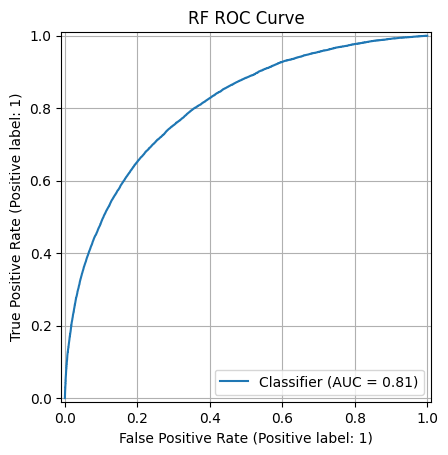

🔍 Evaluating: HistGB
Accuracy: 0.7707
ROC AUC: 0.8111
HistGB Best CV Score (train CV): 0.5548
HistGB Best Params: OrderedDict({'learning_rate': 0.1460907636676245, 'max_depth': 3, 'max_iter': 279, 'min_samples_leaf': 99})

HistGB Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82     57006
         1.0       0.45      0.72      0.55     16394

    accuracy                           0.74     73400
   macro avg       0.68      0.73      0.69     73400
weighted avg       0.80      0.74      0.76     73400

HistGB Confusion Matrix:
[[42607 14399]
 [ 4610 11784]]


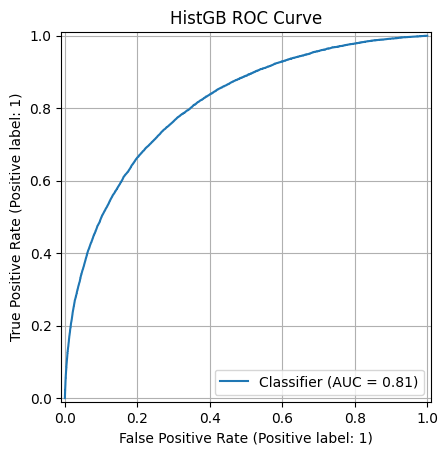

🔍 Evaluating: HistGB_recall
Accuracy: 0.7410
ROC AUC: 0.8107
HistGB_recall Best CV Score (train CV): 0.7229
HistGB_recall Best Params: OrderedDict({'learning_rate': 0.23762608741331417, 'max_depth': 3, 'max_iter': 176, 'min_samples_leaf': 96})

HistGB_recall Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82     57006
         1.0       0.45      0.72      0.55     16394

    accuracy                           0.74     73400
   macro avg       0.68      0.73      0.69     73400
weighted avg       0.80      0.74      0.76     73400

HistGB_recall Confusion Matrix:
[[42556 14450]
 [ 4564 11830]]


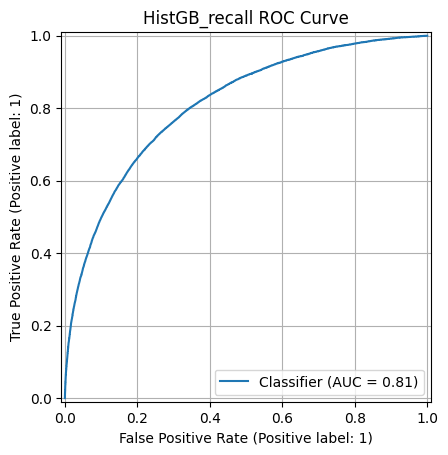

In [32]:
for name, model in [("RF", rf_search), ("HistGB", hist_search), ("HistGB_recall" , hist_search_2)]:
    print(f"🔍 Evaluating: {name}")

    rf_accuracy = accuracy_score(y_test, y_pred)
    rf_roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"Accuracy: {rf_accuracy:.4f}")
    print(f"ROC AUC: {rf_roc_auc:.4f}")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"{name} Best CV Score (train CV): {model.best_score_:.4f}")
    print(f"{name} Best Params: {model.best_params_}\n")

    print(f"{name} Classification Report:\n{classification_report(y_test, y_pred)}")

    print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{name} ROC Curve")
    plt.grid(True)
    plt.show()

## SHAP implementation

In [33]:
import shap

best_model = hist_search.best_estimator_

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
explainer = shap.TreeExplainer(best_model)

In [35]:
shap_values = explainer.shap_values(X_test)

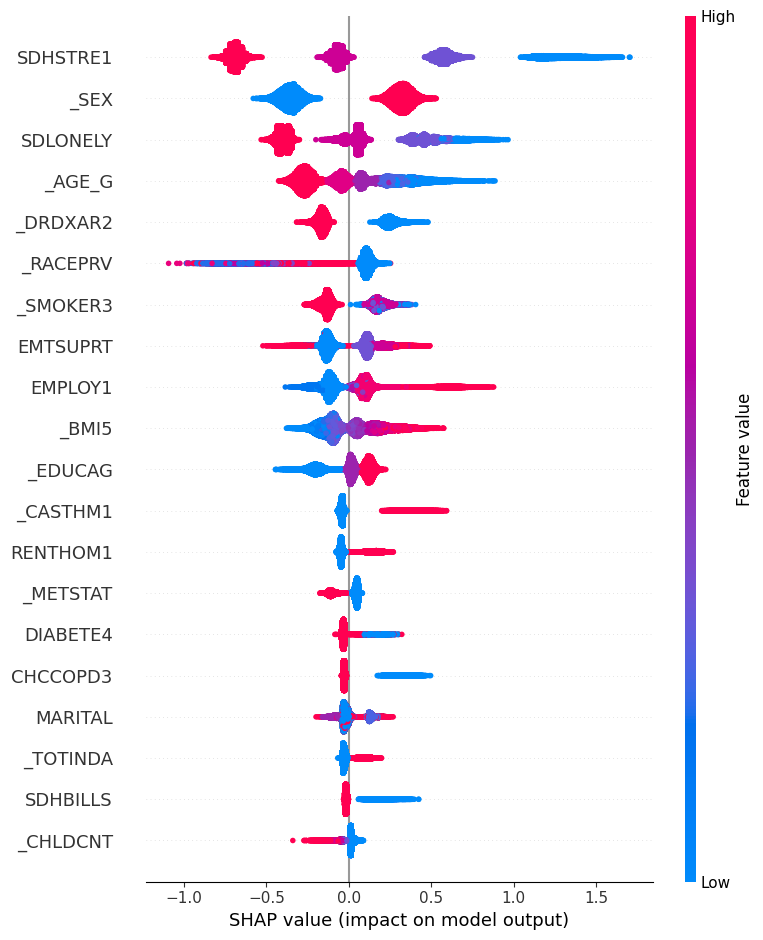

In [ ]:
shap.summary_plot(shap_values, X_test)

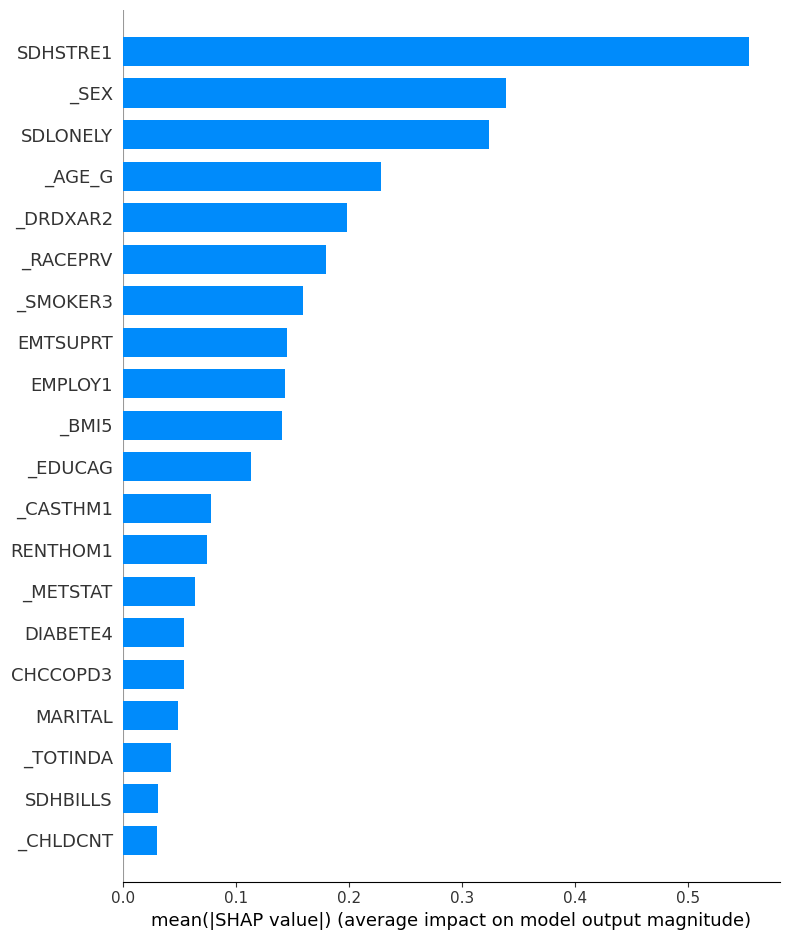

In [37]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [38]:
# SHAP force plot untuk 1 prediksi
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])


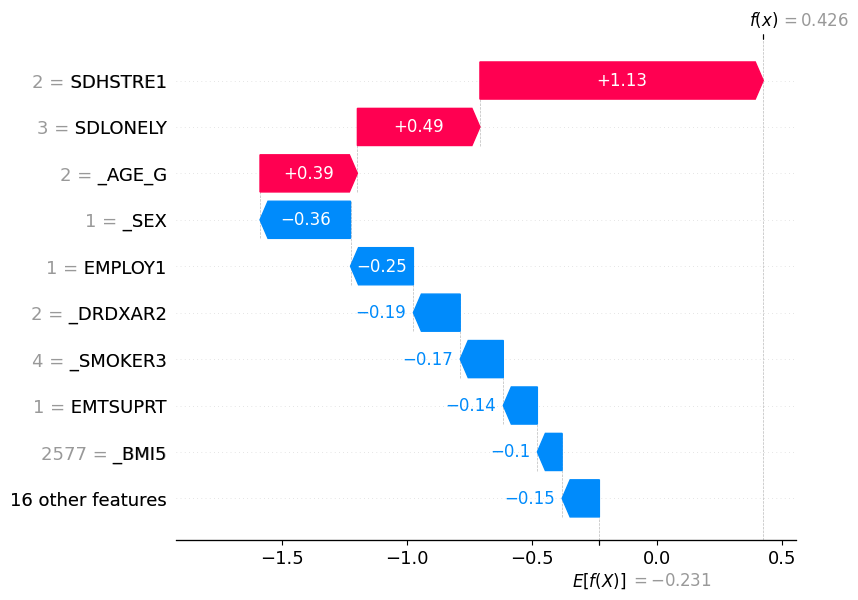

In [46]:
instance = X_train.iloc[[0]]

exp = shap.Explainer(best_model, X_train)
shap_val= exp(instance)
shap.plots.waterfall(shap_val[0])

🧠 Depresi:


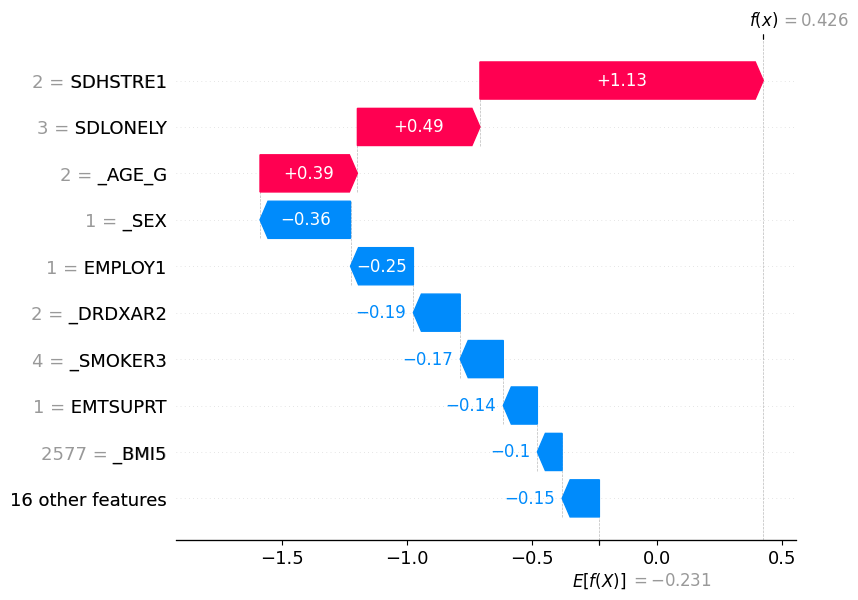

🙂 Non-Depresi:


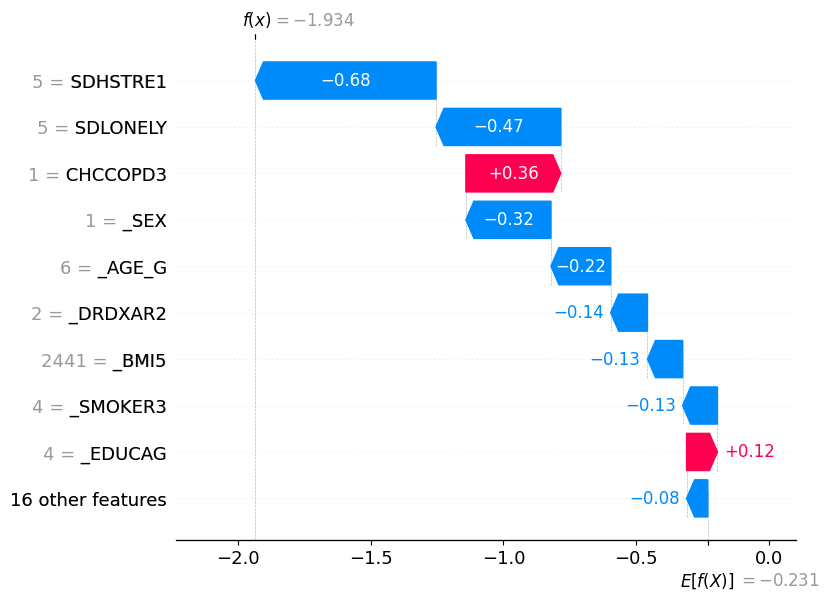

In [47]:
# Ambil 1 instance dengan label 1 (depresi)
idx_depresi = y_train[y_train == 1].index[0]
instance_depresi = X_train.loc[[idx_depresi]]

# Ambil 1 instance dengan label 0 (non-depresi)
idx_non_depresi = y_train[y_train == 0].index[0]
instance_non_depresi = X_train.loc[[idx_non_depresi]]

# Inisialisasi SHAP Explainer (sekali saja)
explainer = shap.Explainer(best_model, X_train)

# Hitung SHAP values
shap_val_depresi = explainer(instance_depresi)
shap_val_non_depresi = explainer(instance_non_depresi)

# Tampilkan waterfall plot untuk masing-masing
print("🧠 Depresi:")
shap.plots.waterfall(shap_val_depresi[0])

print("🙂 Non-Depresi:")
shap.plots.waterfall(shap_val_non_depresi[0])

# Saving model

In [48]:
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

In [50]:
best_model = hist_search.best_estimator_
best_model.fit(X_full, y_full)

HistGradientBoostingClassifier(class_weight='balanced',
                               learning_rate=0.1460907636676245, max_depth=3,
                               max_iter=279, min_samples_leaf=99,
                               random_state=42)

In [53]:
import joblib

joblib.dump(best_model, 'final_model2.pkl')
print("Model saved ke 'final_model2pkl'")

Model saved ke 'final_model2pkl'
